### **Models Notebook:**
This notebook containd models training and comparison. 

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
#import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import tensorflow as tf

In [5]:
df = pd.read_csv("your_data.csv")
df = df.drop(columns=["Unnamed: 0"])
#outliers removal using IQR method
#inter quartile range is sorting the data in (sorting is done in temp memory)
#ascending order and then dividing it into 4 equal parts 25%
#then we get the mid of first and third part WHY NOT Q3? 3shan de akbr data in my dataset
# and then we get the inter quartile range by subtracting
# the mid of first part from the mid of fourth part
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
is_outlier_cell = (df < lower_bound) | (df > upper_bound)
has_outlier_row = is_outlier_cell.any(axis=1)
# Keep only the rows that do NOT have outliers
df_clean = df[~has_outlier_row]

X = df_clean.drop("smoking", axis=1)
y = df_clean["smoking"]

In [10]:
from sklearn.preprocessing import MinMaxScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# x_scaled da by3ml calc ll mean w std l kol col. then value-mean/std 
#leh b3ml kda ? 3shan a7wl el data l std normal dist.
#why? lw 3nd kol el range of numbers kber el model hyshof en da more important
#w da by2ll el accuracy and make model slower 

minmax = MinMaxScaler()
X_normalized = minmax.fit_transform(X_scaled)

# normal data splitting 60% train, 20% valid, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

print("Train size:", X_train.shape)
print("Valid size:", X_valid.shape)
print("Test size:", X_test.shape)

Train size: (78843, 10)
Valid size: (26281, 10)
Test size: (26281, 10)


In [20]:
def build_model(neurons=64, dropout_rate=0.3, learning_rate=0.001):
    #sequential de zy el pipeline 
    model = keras.Sequential([
        #dense is to make it FC 
        layers.Dense(neurons, activation='relu', 
                    input_shape=(X_train.shape[1],)),
        layers.Dropout(dropout_rate),  
        
        layers.Dense(neurons // 2, activation='relu'),
        layers.Dropout(dropout_rate),
        #1 as o/p is smoker or not smoker 
        #sigmoid 3shan a7wl el o/p l prob between 0 and 1
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model
    

In [22]:
# Build basic model
model = build_model()

# Show model structure
model.summary()

# Train it
history = model.fit(
    X_train, y_train,
    epochs=30,                        # how many times to go through data
    batch_size=32,                    # how many samples per update
    validation_data=(X_valid, y_valid),  # watch performance on valid set
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6869 - loss: 0.5834 - val_accuracy: 0.6978 - val_loss: 0.5669
Epoch 2/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6981 - loss: 0.5702 - val_accuracy: 0.7031 - val_loss: 0.5638
Epoch 3/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6993 - loss: 0.5672 - val_accuracy: 0.7036 - val_loss: 0.5616
Epoch 4/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7022 - loss: 0.5667 - val_accuracy: 0.7023 - val_loss: 0.5643
Epoch 5/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7020 - loss: 0.5652 - val_accuracy: 0.7043 - val_loss: 0.5646
Epoch 6/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7044 - loss: 0.5639 - val_accuracy: 0.7040 - val_loss: 0.5600
Epoch 7/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7062 - loss: 0.5633 - val_accuracy: 0.7074 - val_loss: 0.5601
Epoch 8/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7049 - loss: 0

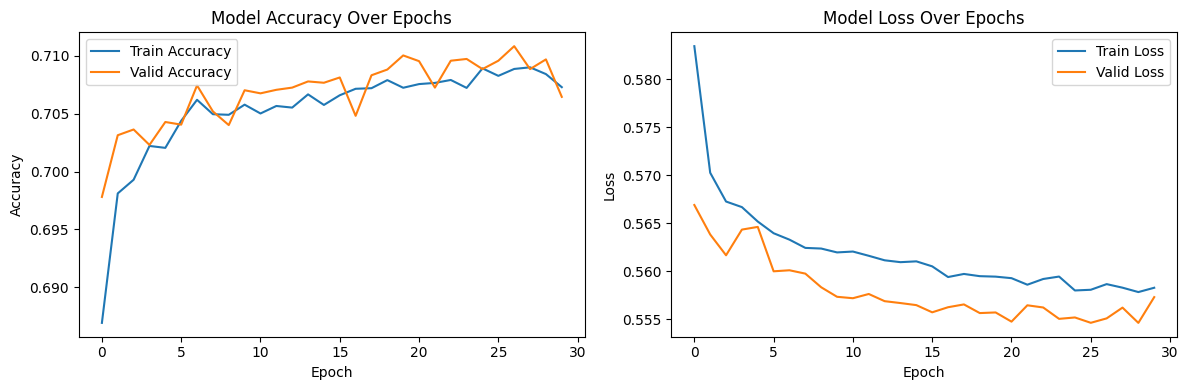

In [23]:
# Plot accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Valid Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Valid Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

822/822 ━━━━━━━━━━━━━━━━━━━━ 1s 810us/step
=== Neural Network Results ===
Accuracy: 0.7069746204482326
Precision: 0.662085308056872
Recall: 0.6280909990108803
F1-score: 0.644640302708689


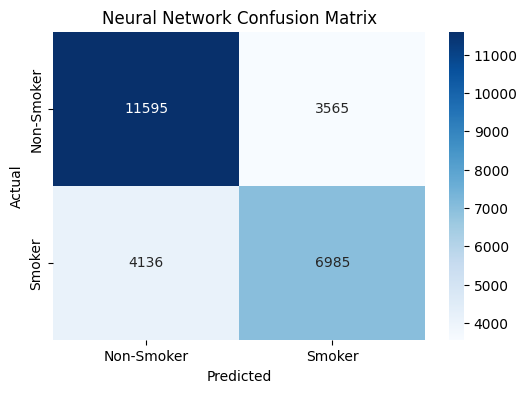

In [24]:
# Predict on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Print metrics
print("=== Neural Network Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Smoker','Smoker'],
            yticklabels=['Non-Smoker','Smoker'])
plt.title('Neural Network Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier

# Use the best parameters found
# Create a wrapper for the keras model
keras_model = KerasClassifier(model=build_model, epochs=30, batch_size=32, verbose=0)

# Define hyperparameter grid
param_grid = {
    'model__neurons': [32, 64, 128],
    'model__dropout_rate': [0.2, 0.3, 0.5],
    'model__learning_rate': [0.001, 0.01]
}

# Perform grid search
grid_search = GridSearchCV(keras_model, param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_

final_model = build_model(
    neurons=best_params['model__neurons'],
    dropout_rate=best_params['model__dropout_rate'],
    learning_rate=best_params['model__learning_rate']
)

# Train final model
history_final = final_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    verbose=1
)

# Evaluate on test set
y_pred_final = (final_model.predict(X_test) > 0.5).astype(int).flatten()

print("=== Final Tuned Neural Network ===")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1-score:", f1_score(y_test, y_pred_final))

In [25]:
results = pd.DataFrame({
    'Model': ['Neural Network (Basic)', 'Neural Network (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_final)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_final)
    ]
})
print(results)


NameError: name 'y_pred_final' is not defined

### Logistic Regression Model
A logistic regression model is trained as a simple linear classification approach. 
It models the probability of smoking based on input features.

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Model Evaluation
We evaluate the model using accuracy, precision, recall, and F1-score. 
These metrics help assess the model's classification performance from different perspectives.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_log = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

Accuracy: 0.690841292188273
Precision: 0.6498299659931986
Recall: 0.5842100530527831
F1-score: 0.6152753444765378


Hyperparameter Tuning:

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

### Probabilitic model: Gaussian Naive Bayes

In [13]:
class ManualGaussianNB:

    def fit(self, X, y):

        self.classes = np.unique(y)

        self.mean = {}
        self.var = {}
        self.priors = {}

        for c in self.classes:

            X_c = X[y == c]

            self.mean[c] = np.mean(X_c, axis=0)

            self.var[c] = np.var(X_c, axis=0)

            self.priors[c] = X_c.shape[0] / X.shape[0]


    def gaussian_pdf(self, class_idx, x):

        mean = self.mean[class_idx]

        var = self.var[class_idx]

        numerator = np.exp(
            -((x - mean) ** 2) / (2 * var)
        )

        denominator = np.sqrt(2 * np.pi * var)

        return numerator / denominator
    

    def predict_sample(self, x):

        posteriors = []

        for c in self.classes:

            prior = np.log(self.priors[c])

            conditional = np.sum(
                np.log(
                    self.gaussian_pdf(c, x)
                )
            )

            posterior = prior + conditional

            posteriors.append(posterior)

        return self.classes[np.argmax(posteriors)]
    
    def predict(self, X):

        predictions = [
            self.predict_sample(x)
            for x in X
        ]

        return np.array(predictions)

In [ ]:
Probmodel = ManualGaussianNB()

Probmodel.fit(X_train, y_train)
y_pred_NB = Probmodel.predict(X_test)

print("Predictions Score:")
print("Accuracy:", accuracy_score(y_test, y_pred_NB))
print("Precision:", precision_score(y_test, y_pred_NB))
print("Recall:", recall_score(y_test, y_pred_NB))
print("F1-score:", f1_score(y_test, y_pred_NB))

Predictions Score:
Accuracy: 0.689205129180777
Precision: 0.6247359972966123
Recall: 0.6649581872133801
F1-score: 0.6442198797804687


Training model using only the top features selected from the feature engineering phase:

In [15]:
import json

In [16]:
with open("top_features.json", "r") as f:
    top_features = json.load(f)

df_top = pd.read_csv("your_data.csv")

for feature in df_top.columns:
    if feature not in top_features and feature != "smoking":
        df_top = df_top.drop(columns=[feature])

print("Top features dataset shape:", df_top.shape)

Top features dataset shape: (159256, 5)


In [17]:
Q1 = df_top.quantile(0.25)
Q3 = df_top.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
is_outlier_cell = (df_top < lower_bound) | (df_top > upper_bound)
has_outlier_row = is_outlier_cell.any(axis=1)
# Keep only the rows that do NOT have outliers
df_clean = df_top[~has_outlier_row]

X_top = df_clean.drop("smoking", axis=1)
y_top = df_clean["smoking"]

In [18]:
scaler = StandardScaler()
X_scaled_top = scaler.fit_transform(X_top)

# normal data splitting 60% train, 20% valid, 20% test
X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_scaled_top, y_top, test_size=0.2, random_state=42
)
X_train_top, X_valid_top, y_train_top, y_valid_top = train_test_split(
    X_train_top, y_train_top, test_size=0.25, random_state=42
)

print("Train size:", X_train_top.shape)
print("Valid size:", X_valid_top.shape)
print("Test size:", X_test_top.shape)

Train size: (87234, 4)
Valid size: (29079, 4)
Test size: (29079, 4)


In [19]:
Probmodel_top = ManualGaussianNB()

Probmodel_top.fit(X_train_top, y_train_top)
y_pred_top = Probmodel_top.predict(X_test_top)

print("Predictions Score:")
print("Accuracy:", accuracy_score(y_test_top, y_pred_top))
print("Precision:", precision_score(y_test_top, y_pred_top))
print("Recall:", recall_score(y_test_top, y_pred_top))
print("F1-score:", f1_score(y_test_top, y_pred_top))

Predictions Score:
Accuracy: 0.6739915402868049
Precision: 0.6191750086296168
Recall: 0.5860970429668355
F1-score: 0.6021821233738984


Using the top features, it didn't achieve higher accuracy

### ***Model Comparison***

In [ ]:
models = ['Logistic Regression', 'Naive Bayes', 'Neural Network']

accuracy = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_NB),
    accuracy_score(y_test, y_pred_final)
]

precision = [
    precision_score(y_test, y_pred_log),
    precision_score(y_test, y_pred_NB),
    precision_score(y_test, y_pred_final)
]

recall = [
    recall_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_NB),
    recall_score(y_test, y_pred_final)
]

f1 = [
    f1_score(y_test, y_pred_log),
    f1_score(y_test, y_pred_NB),
    f1_score(y_test, y_pred_final)
]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
})

print(comparison)